In [4]:
import numpy as np

def jacobi(A, b, x0, tol, max_iterations):
    n = len(b)
    x = x0.copy()
    errors = []
    
    for k in range(max_iterations):
        x_new = np.zeros_like(x)
        
        for i in range(n):
            s = sum(A[i][j] * x[j] for j in range(n) if j != i)
            x_new[i] = (b[i] - s) / A[i][i]
        
        error = np.linalg.norm(x_new - x, ord=np.inf)
        errors.append(error) 
        
# Check for convergence
        if np.linalg.norm(x_new - x, ord=np.inf) < tol:
            return x_new, k, errors
        
        x = x_new
        
    return x, max_iterations, errors

In [5]:
import numpy as np

def gauss_seidel(A, b, x0, tol, max_iterations):
    n = len(b)
    x = x0.copy()
    errors = []
    
    for k in range(max_iterations):
        x_new = x.copy()
        
        for i in range(n):
            s1 = sum(A[i][j] * x_new[j] for j in range(i)) # Using already updated values
            s2 = sum(A[i][j] * x[j] for j in range(i + 1, n)) # Using old values
            x_new[i] = (b[i] - s1 - s2) / A[i][i]

        error = np.linalg.norm(x_new - x, ord=np.inf)
        errors.append(error)
        
# Check for convergence
        if np.linalg.norm(x_new - x, ord=np.inf) < tol:
            return x_new, k, errors
        x = x_new
        
        
    return x, max_iterations, errors


Tolerance:0.001

Jacobi
Solution: [ 3.0000225  -2.50000266  6.99998104]
Iterations: 3

Gauss-Seidel
Solution: [ 3.00000035 -2.50000004  6.99999999]
Iterations: 3


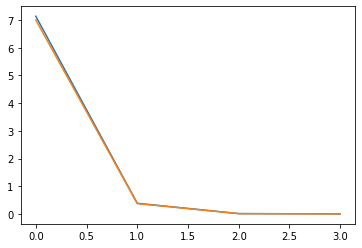


Tolerance:1e-06

Jacobi
Solution: [ 3.  -2.5  7. ]
Iterations: 6

Gauss-Seidel
Solution: [ 3.  -2.5  7. ]
Iterations: 4


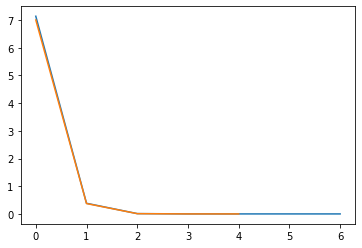


Tolerance:1e-09

Jacobi
Solution: [ 3.  -2.5  7. ]
Iterations: 8

Gauss-Seidel
Solution: [ 3.  -2.5  7. ]
Iterations: 6


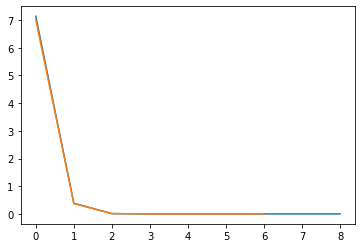

In [6]:
A = np.array([[3,-0.1,-0.2],
              [0.1,7,-0.3],
              [0.3,-0.2,10]])

b = np.array([7.85,-19.3,71.4])

x0 = np.zeros(3)
tolerances = [1e-3, 1e-6, 1e-9]
max_iterations = 100

# Asked Chat GPT why I was getting an error when trying to set the tolerance, so I created a list and indented
for tol in tolerances:
    print(f"\nTolerance:{tol}")

    solution ,iterations ,errors_j = jacobi(A, b, x0, tol, max_iterations)
    print("\nJacobi")
    print(f"Solution: {solution}")
    print(f"Iterations: {iterations}")

    solution,iterations ,errors_g = gauss_seidel(A, b, x0, tol, max_iterations)
    print("\nGauss-Seidel")
    print(f"Solution: {solution}")
    print(f"Iterations: {iterations}")

    import matplotlib.pyplot as plt
    plt.figure()
    plt.plot(errors_j, label="Jacobi")
    plt.plot(errors_g, label="Gauss-Seidel")
    plt.show()
    
# With a smaller tolerance there are more iterations and a larger tolernace there are fewer iterations.